**Author:** Christopher Millward<br>
**Date:** June 125, 2026

This is a continuation of the `01-cm-data-orthonormality-audit.ipynb` notebook. Dan cleaned up one data file and sent it back to me to test for orthonormality. We'll analyze it here. If it looks good, he'll run all of the files and send me the whole batch.

---

I'm going to perform the following audits:
1. Calculate how far away from orthonormality each R matrix is. 
2. Visualize the distributions of these variances
3. Plot the variances on a time series to assess stability / drift.

In [7]:
# set root folder to project root
import os 
import sys

root_path = os.path.abspath(os.path.join(".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

In [8]:
# Import the data
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from utils.kinematics.general_helpers import create_rotation_matrices

fpath = '../data/temporary/1_R_MATRICES 4-8-2015'
data = np.loadtxt(fpath, delimiter='\t', skiprows=1, usecols=range(1, 19))

In [9]:
# build matrices
matrices = create_rotation_matrices(data, 'R')

# calculate variance from orthonormality
I = np.eye(3)
ortho_variance_arrays = (np.transpose(matrices, axes=(0, 2, 1)) @ matrices - I)
variances = np.linalg.norm(ortho_variance_arrays, axis=(1, 2))


plot_data = pd.DataFrame(variances, columns=["variance"])
print(plot_data.describe().to_markdown())

|       |    variance |
|:------|------------:|
| count | 1.23759e+06 |
| mean  | 0.000137768 |
| std   | 3.18184e-05 |
| min   | 6.85894e-06 |
| 25%   | 0.000116282 |
| 50%   | 0.000138693 |
| 75%   | 0.000160059 |
| max   | 0.000257248 |


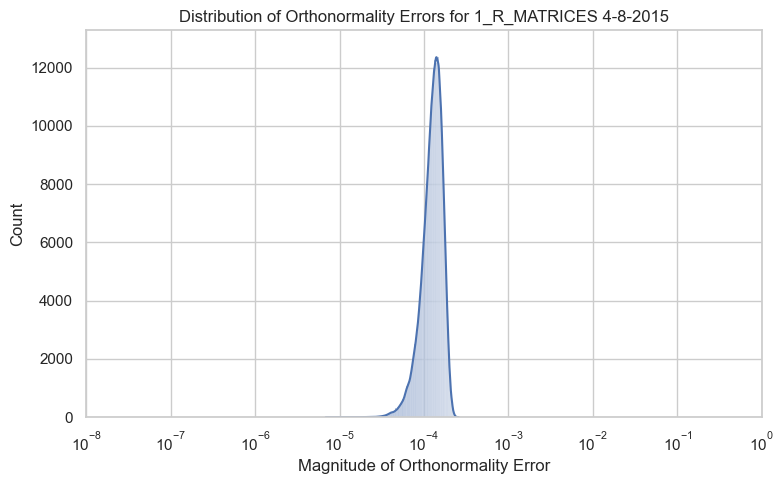

In [10]:
# Plot distribution
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(8, 5))

sns.histplot(
    data=plot_data,
    kde=True,
    legend=False,
)

plt.xscale("log")
plt.title(f"Distribution of Orthonormality Errors for {fpath.split('/')[-1]}")
plt.xlabel("Magnitude of Orthonormality Error")
plt.ylabel("Count")
plt.xlim(1e-8, 1)
plt.tight_layout()
plt.show()

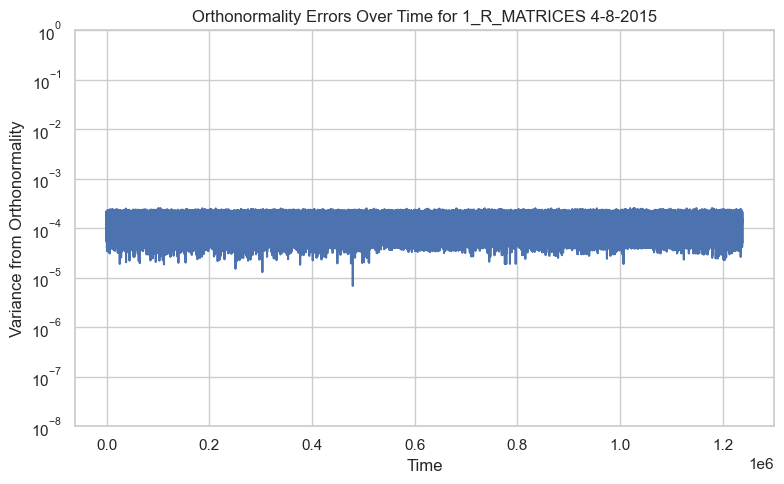

In [11]:
# Plot the orthonormality errors on a time-series
sns.set_theme(style="whitegrid", context="notebook")
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=plot_data,
    x=plot_data.index,
    y="variance",
    legend = False,
)

plt.yscale("log")
plt.title(f"Orthonormality Errors Over Time for {fpath.split('/')[-1]}")
plt.xlabel("Time")
plt.ylabel("Variance from Orthonormality")
plt.ylim(1e-8, 1)
plt.tight_layout()
plt.show()

The variances seem very stable, hovering 0.5 magnitudes around 1e-5. This is within an accepted range, allowing us to accept that the rotation profiles will be preserved through the motion capture. Dan is running the full batch of processing now. Once I have that data, I'll re-run the audit and see if the entire dataset is this clean. 